## Employment-Trend Analysis

By Ken Burchfiel

Released under the MIT License

This notebook was used to create the data on which my employment-trends HTML page is based.

In [1]:
import pandas as pd
pd.set_option('display.max_columns', 1000)
import plotly.express as px
import numpy as np

In [2]:
df = pd.read_stata(
'/home/kjb3/D1V1/kjb3largefiles/large_programming/datasets/cps/cps_00017.dta',
convert_categoricals=True)

# Note: This dataset was generated via https://cps.ipums.org/. 

# df

In [3]:
df['employed'] = np.where(df['empstat'].isin(['at work', 'has job, not at work last week']),
                          1, 0)

In [4]:
df['employed'].value_counts()

employed
0    12238656
1    10881987
Name: count, dtype: int64

In [5]:
df['empstat'].value_counts()

empstat
at work                           10475328
niu                                4259600
nilf, retired                      3661398
nilf, other                        2629556
nilf, unable to work                979983
unemployed, experienced worker      572757
has job, not at work last week      406659
armed forces                         77860
unemployed, new worker               57502
Name: count, dtype: int64

In [6]:
df['age_as_int'] = df['age'].astype('str').replace('under 1 year', '0').astype('int')

In [7]:
df['age_range'] = np.select(condlist = [df['age_as_int'] <= 21,
                      df['age_as_int'] <= 24,
                      df['age_as_int'] <= 29,
                      df['age_as_int'] <= 34,
                      df['age_as_int'] <= 39,
                      df['age_as_int'] <= 44,
                      df['age_as_int'] <= 49,
                      df['age_as_int'] <= 54,
                      df['age_as_int'] <= 59,
                      df['age_as_int'] >= 60],

          choicelist = ['Under 22',
                        '22-24',
                        '25-29',
                        '30-34',
                        '35-39',
                        '40-44',
                        '45-49',
                        '50-54',
                        '55-59',
                        '60 or older'],
          default = 'Missing age')
          

In [8]:
df['age_range'].value_counts()

age_range
Under 22       6250220
60 or older    5570194
55-59          1571008
50-54          1567240
30-34          1497882
45-49          1481519
35-39          1479378
40-44          1472392
25-29          1423921
22-24           806889
Name: count, dtype: int64

In [9]:
df['month_code'] = df['month'].map({'january':'01', 'february':'02', 
'march':'03', 'april':'04', 'may':'05', 'june':'06', 'july':'07', 'august':'08',
'september':'09', 'october':'10', 'november':'11', 'december':'12'})
                                      

In [10]:
df['quarter'] = df['month'].map({'january':'Q1', 'february':'Q1', 
'march':'Q1', 'april':'Q2', 'may':'Q2', 'june':'Q2', 'july':'Q3', 'august':'Q3',
'september':'Q3', 'october':'Q4', 'november':'Q4', 'december':'Q4'})
                                      

In [11]:
df['half'] = df['quarter'].map({'Q1':'H1', 'Q2':'H1', 'Q3':'H2', 'Q4':'H2'})
                                      

In [12]:
df['year_and_month'] = df['year'].astype('str')+'-'+df['month_code'].astype('str')

In [13]:
df['year_and_quarter'] = df['year'].astype('str')+'-'+df['quarter']

In [14]:
df['year_and_half'] = df['year'].astype('str')+'-'+df['half']

In [15]:
df['uhrsworkt_revised'] = df['uhrsworkt'].astype('str').replace(
{'niu':-1, 'hours vary':-1}).astype('int')
df['FTE'] = np.where(df['uhrsworkt_revised'] >= 35, 1, 0)

In [16]:
df['FTE'].value_counts()

FTE
0    14832357
1     8288286
Name: count, dtype: int64

In [17]:
df['occ2010'].value_counts()

occ2010
niu                                                                                                    11541348
miscellaneous managers, including funeral service managers and postmasters and mail superintendents      369371
driver/sales workers and truck drivers                                                                   260863
elementary and middle school teachers                                                                    247029
first-line supervisors of retail sales workers                                                           244842
                                                                                                         ...   
textile bleaching and dyeing, and cutting machine setters, operators, and tenders                           385
podiatrists                                                                                                 378
brokerage clerks                                                                                

In [18]:
df['Count'] = 1

Employment totals by occupation and year/month:

In [19]:
df_occ_by_year = df.query("(occ2010 != 'niu') & (employed == 1)").pivot_table(
index = ['occ2010', 'year', 'year_and_half', 'year_and_quarter', 'year_and_month'], 
values = ['wtfinl', 'Count'], aggfunc = 'sum').reset_index()
#df_occ_by_year.to_json('datasets/employment_by_occupation_and_month.json')
df_occ_by_year

,occ2010,year,year_and_half,year_and_quarter,year_and_month,Count,wtfinl
0,chief executives and legislators,2010,2010-H1,2010-Q1,2010-01,706,1.537897e+06
1,chief executives and legislators,2010,2010-H1,2010-Q1,2010-02,677,1.420215e+06
2,chief executives and legislators,2010,2010-H1,2010-Q1,2010-03,716,1.514071e+06
3,chief executives and legislators,2010,2010-H1,2010-Q2,2010-04,718,1.524504e+06
4,chief executives and legislators,2010,2010-H1,2010-Q2,2010-05,685,1.464356e+06
...,...,...,...,...,...,...,...
90361,"miscellaneous material moving workers, includi...",2025,2025-H2,2025-Q4,2025-12,18,6.543234e+04
90362,"miscellaneous material moving workers, includi...",2026,2026-H1,2026-Q1,2026-01,13,4.382561e+04
90363,"miscellaneous material moving workers, includi...",2026,2026-H1,2026-Q1,2026-02,21,7.463515e+04
90364,"miscellaneous material moving workers, includi...",2026,2026-H1,2026-Q1,2026-03,19,8.849974e+04


Exporting the dataset into a format that can get read more easily by Danfo.js:

(See https://danfo.jsdata.org/getting-started#browser)

In [20]:
with open('datasets/df_occ_by_year.txt', mode = 'w') as file:
    file.write(str(df_occ_by_year.to_dict(orient='records')))

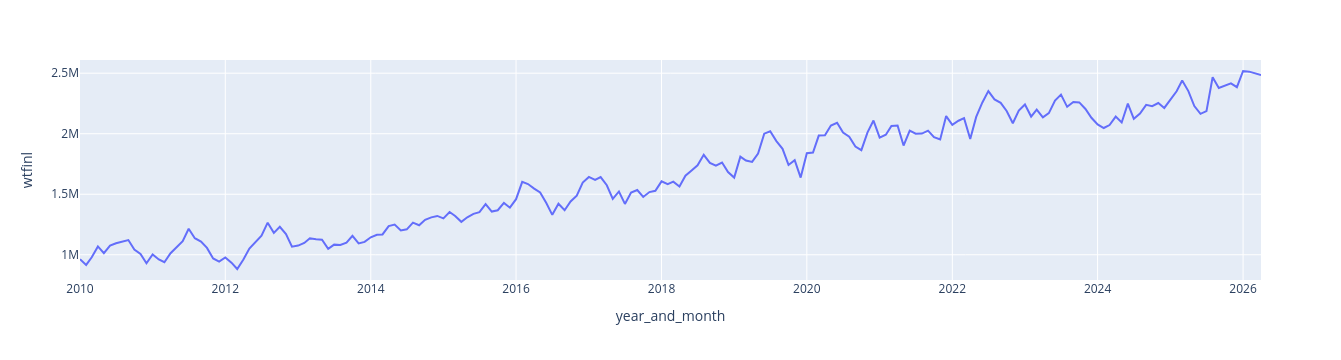

In [21]:
px.line(df_occ_by_year.query("occ2010 == 'software developers, applications and systems software'"),
       x = 'year_and_month', y = 'wtfinl', hover_data = 'Count')

Employment totals by occupation, year, and age range:

In [22]:
df_occ_by_year_and_age = df.query("(occ2010 != 'niu') & (employed == 1)").pivot_table(
index = ['occ2010', 'age_range', 'year', 'year_and_half', 'year_and_quarter', 'year_and_month'], 
values = ['wtfinl', 'Count'], aggfunc = 'sum').reset_index()
#df_occ_by_year_and_age.to_json('datasets/employment_by_occupation_age_and_month.json')
df_occ_by_year_and_age


,occ2010,age_range,year,year_and_half,year_and_quarter,year_and_month,Count,wtfinl
0,chief executives and legislators,22-24,2010,2010-H1,2010-Q1,2010-01,4,12265.0767
1,chief executives and legislators,22-24,2010,2010-H1,2010-Q1,2010-02,3,10069.9672
2,chief executives and legislators,22-24,2010,2010-H1,2010-Q1,2010-03,3,5723.8677
3,chief executives and legislators,22-24,2010,2010-H1,2010-Q2,2010-04,2,3409.3147
4,chief executives and legislators,22-24,2010,2010-H1,2010-Q2,2010-05,1,591.0935
...,...,...,...,...,...,...,...,...
748039,"miscellaneous material moving workers, includi...",Under 22,2025,2025-H2,2025-Q4,2025-12,1,3342.0088
748040,"miscellaneous material moving workers, includi...",Under 22,2026,2026-H1,2026-Q1,2026-01,1,3228.3517
748041,"miscellaneous material moving workers, includi...",Under 22,2026,2026-H1,2026-Q1,2026-02,3,15565.3641
748042,"miscellaneous material moving workers, includi...",Under 22,2026,2026-H1,2026-Q1,2026-03,3,20693.7058


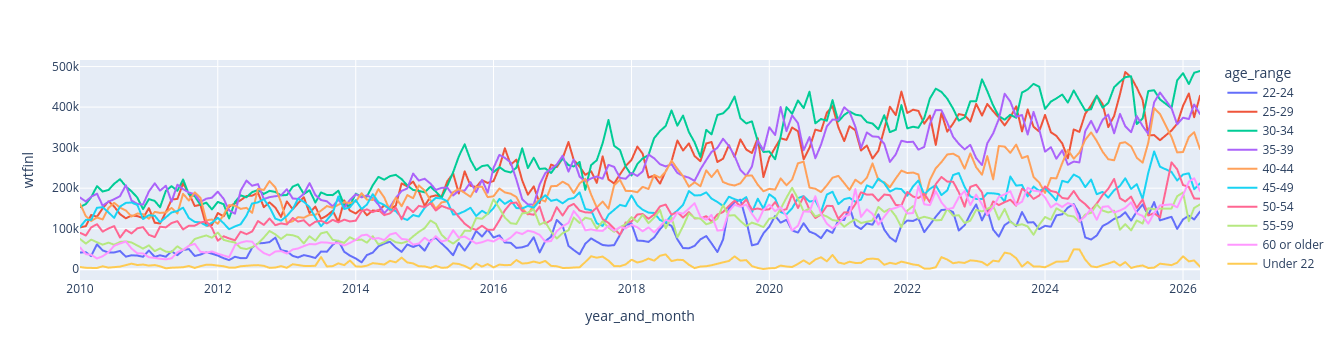

In [23]:
px.line(df_occ_by_year_and_age.query(
"occ2010 == 'software developers, applications and systems software'"),
x = 'year_and_month', y = 'wtfinl', hover_data = 'Count', color = 'age_range')

## Creating option elements that can then get incorporated within our HTML page:

In [24]:
unique_occupations = [occ for occ in df_occ_by_year['occ2010'].unique()]
unique_occupations.sort()

In [25]:
for occupation in unique_occupations:
    print(f'<option value="{occupation}">{occupation.capitalize()}</option>')

<option value="accountants and auditors">Accountants and auditors</option>
<option value="actors">Actors</option>
<option value="actuaries">Actuaries</option>
<option value="adhesive bonding machine operators and tenders">Adhesive bonding machine operators and tenders</option>
<option value="administrative services managers">Administrative services managers</option>
<option value="advertising and promotions managers">Advertising and promotions managers</option>
<option value="advertising sales agents">Advertising sales agents</option>
<option value="aerospace engineers">Aerospace engineers</option>
<option value="agents and business managers of artists, performers, and athletes">Agents and business managers of artists, performers, and athletes</option>
<option value="agricultural and food science technicians">Agricultural and food science technicians</option>
<option value="agricultural and food scientists">Agricultural and food scientists</option>
<option value="agricultural inspector